In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
aep = np.loadtxt("aep.txt")
levels = np.logspace(-2,1,100)

def plot_map(loc, ax=None):
    if ax is None:
        ax = plt.gca()
    lon, lat = np.loadtxt("jp-500-grid.txt",unpack = True)
    clat, clon = np.loadtxt("hr-coast-japan.txt",unpack=True)

    ax.plot(clon, clat,"-k")
    ax.plot(lon[loc],lat[loc],"ro")
    ax.set_xticks([])
    ax.set_yticks([])

def plot_hazard(exceedance, title):

    plt.plot(levels, exceedance, "-b")
    plt.semilogx()
    plt.xticks([0.01,0.1,0.5,1,5,10],[0.01,0.1,0.5,1,5,10])
    plt.grid()
    plt.xlabel("Maximum Wave Height [m]")
    plt.ylabel("Exceedance Rate")
    plt.title(f"Hazard Curve: {title}")

def plot_prob(exceedance, title, interval, prefix):
    prob = 1 - np.exp(-exceedance*interval)

    plt.plot(levels, prob, "-b")
    plt.semilogx()
    plt.xticks([0.01,0.1,0.5,1,5,10],[0.01,0.1,0.5,1,5,10])
    plt.grid()
    plt.xlabel("Maximum Wave Height [m]", fontsize = 10)
    plt.ylabel(f"{interval}-year Exceedance Probability", fontsize=10)
    plt.title(f"{prefix} Hazard Curve: {title}", fontsize = 14)

def plot_hazard_map(loc, title, interval=None, prefix=None):
    fig, ax_main = plt.subplots(1, 1, figsize=(5, 1.25*3*0.75))

    plt.sca(ax_main)
    exceedance = aep[loc,:]

    if interval==None:
        plot_hazard(exceedance, title)
    else:
        plot_prob(exceedance, title, interval, prefix)

    # Inset map: lower-left corner, slightly above x-axis and right of y-axis
    if loc==294:
        ax_inset = ax_main.inset_axes([0.04, 0.04, 0.32, 0.6])
    else:
        ax_inset = ax_main.inset_axes([0.64, 0.36, 0.32, 0.6])
    plot_map(loc, ax=ax_inset)
    ax_inset.set_facecolor((1, 1, 1, 0.5))

    # fig.savefig(f"hazard-map-{loc}.png", dpi=400)

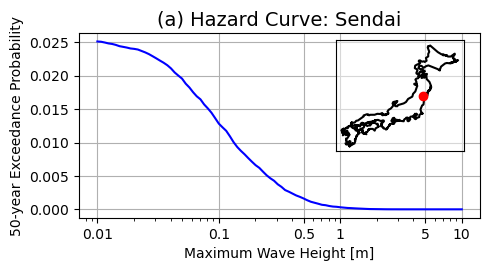

In [9]:
plot_hazard_map(335, "Sendai", 50, "(a)")
plt.tight_layout()
plt.savefig("sendai.png", dpi=500)


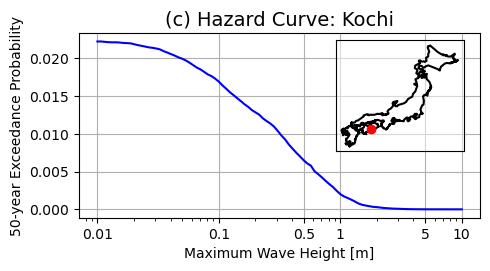

In [8]:
plot_hazard_map(102, "Kochi", 50, "(c)")
plt.tight_layout()
plt.savefig("kochi.png", dpi=500)

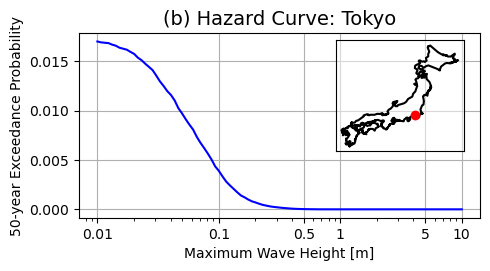

In [13]:
plot_hazard_map(292, "Tokyo", 50, "(b)")
plt.tight_layout()
plt.savefig("tokyo.png", dpi=500)